In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


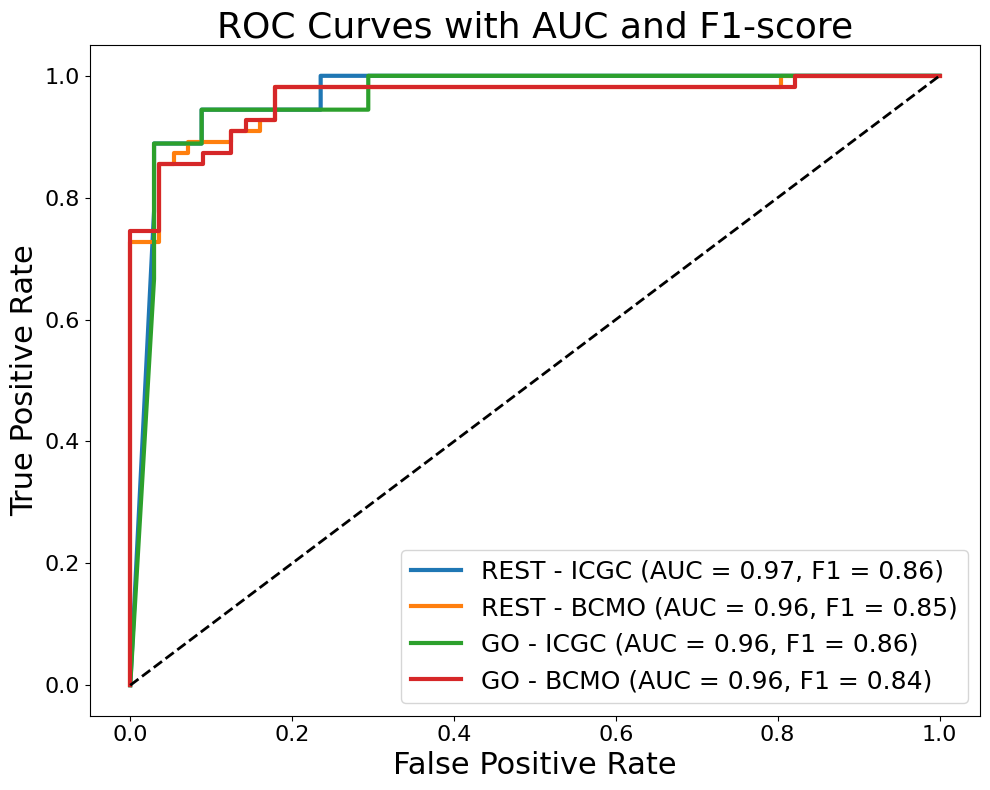

In [2]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# List of files to process
file_paths = [
    "../../PASNet/Output/REST/roc_curve_data_ICGC_validation.txt",
    "../../PASNet/Output/REST/roc_curve_data_BCMO_testing.txt",
    "../../PASNet/Output/GO/roc_curve_data_ICGC_validation.txt",
    "../../PASNet/Output/GO/roc_curve_data_BCMO_testing.txt"
]

# Manually assign F1 scores corresponding to each file
f1_scores = [0.86, 0.85, 0.86, 0.84]

# Plotting
plt.figure(figsize=(10, 8))

for file_path, f1 in zip(file_paths, f1_scores):
    # Read the file (tab-separated, skipping comment lines)
    df = pd.read_csv(file_path, sep="\t", comment='#', names=["FPR", "TPR"])

    # Calculate AUC
    curve_auc = auc(df["FPR"], df["TPR"])

    # Generate label from file path
    method = os.path.basename(os.path.dirname(file_path))   # REST or GO
    dataset = os.path.splitext(os.path.basename(file_path))[0] \
                .replace("roc_curve_data_", "") \
                .replace("_validation", "") \
                .replace("_testing", "")
    label = f"{method} - {dataset} (AUC = {curve_auc:.2f}, F1 = {f1:.2f})"

    # Plot the ROC curve with thicker line
    plt.plot(df["FPR"], df["TPR"], label=label, linewidth=3)

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

# Plot settings with larger labels and title
plt.xlabel("False Positive Rate", fontsize=22)
plt.ylabel("True Positive Rate", fontsize=22)
plt.title("ROC Curves with AUC and F1-score", fontsize=26)
plt.legend(loc="lower right", fontsize=18, frameon=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(False)  # remove grid for cleaner look
plt.gca().set_facecolor('white')
plt.tight_layout()

# Save the figure
plt.savefig("../../figures/AUC_ROC.png", dpi=600)

# Display the plot
plt.show()
